In [ ]:
!pip install yfinance

# use your mobile data to install yfiannce

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8")


In [37]:
start_date = "2025-02-04"
end_date = "2026-02-04"

hdfc = yf.download("HDFCBANK.NS", start=start_date, end=end_date)['Close']
sparc = yf.download("SPARC.NS", start=start_date, end=end_date)['Close']

df = pd.concat([hdfc, sparc], axis=1)

# df.info()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 247 entries, 2025-02-04 to 2026-02-03
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   HDFCBANK.NS  247 non-null    float64
 1   SPARC.NS     247 non-null    float64
dtypes: float64(2)
memory usage: 5.8 KB


In [40]:
df.to_csv("HDFC_SPARC_Closing_Prices.csv", index=True)

In [41]:
df.describe()

Ticker,HDFCBANK.NS,SPARC.NS
count,247.000000,247.000000
mean,952.320942,143.834899
std,51.399736,13.444033
min,827.366455,112.010002
25%,937.149994,133.570000
50%,965.250000,142.610001
75%,992.140472,152.639999
max,1012.900024,198.539993


<Figure size 1000x600 with 0 Axes>

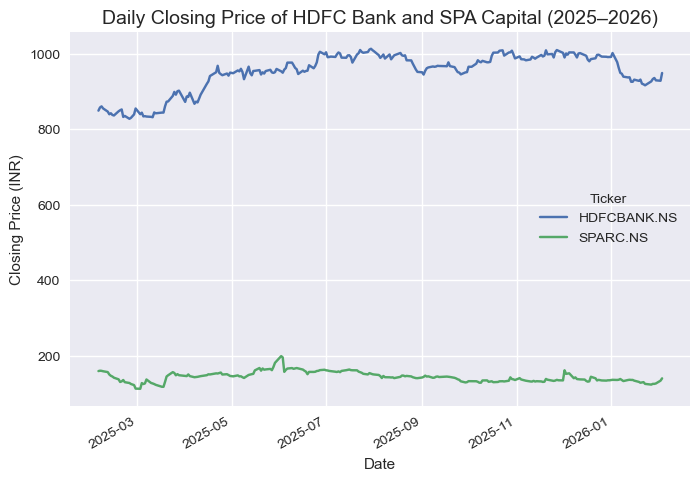

In [91]:
plt.figure(figsize=(10,6))

df.plot()

plt.title("Daily Closing Price of HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid(True)

plt.show()


In [50]:
returns = df.pct_change()
returns.head()

Ticker,HDFCBANK.NS,SPARC.NS
Date,,
2025-02-04,NaN,NaN
2025-02-05,0.009820,0.006169
2025-02-06,0.003481,-0.002440
2025-02-07,-0.006365,-0.006397
2025-02-10,-0.009811,-0.014076


In [92]:
returns = returns.dropna()
returns.describe()

Ticker,HDFCBANK.NS,SPARC.NS
count,246.000000,246.000000
mean,0.000496,0.000002
std,0.009499,0.032697
min,-0.033011,-0.196485
25%,-0.005037,-0.015058
50%,0.000228,-0.002708
75%,0.006190,0.007827
max,0.035720,0.199940


<Figure size 1000x600 with 0 Axes>

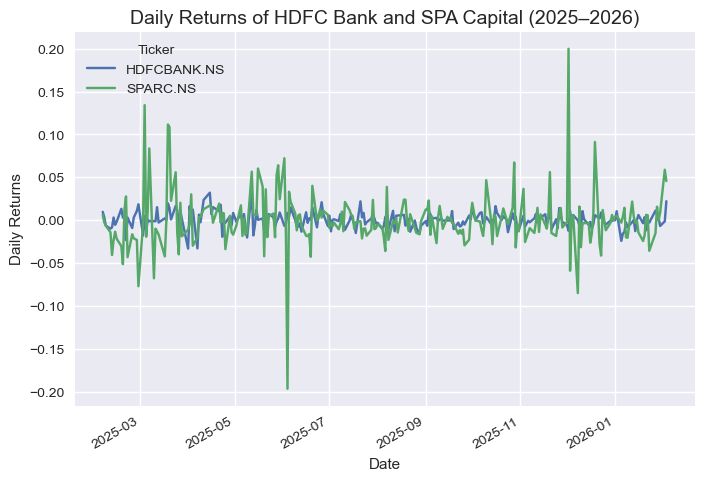

In [90]:
plt.figure(figsize=(10,6))
returns.plot()
plt.title("Daily Returns of HDFC Bank and SPA Capital (2025–2026)", fontsize=14)
plt.ylabel("Daily Returns")
plt.xlabel("Date")
plt.grid(True)
plt.show()


### Compounding Returns

In [74]:
Compounded_returns = (((returns+1).prod()-1)*100).round(2)
Compounded_returns

Ticker
HDFCBANK.NS    11.75
SPARC.NS      -12.12
dtype: float64

### Annualized Returns

In [97]:
annualized_return = Compounded_returns

### Annualized Volatility (Converting volatility for a daily series to yearly)

In [82]:
annualized_vol = returns.std() * (return.shape[1] ** 0.5)
annualized_vol

Ticker
HDFCBANK.NS    0.149286
SPARC.NS       0.513868
dtype: float64

### Skewness

In [93]:
skewness = returns.skew()
skewness

Ticker
HDFCBANK.NS     1.654547
SPARC.NS       12.133483
dtype: float64

### Kurtosis

In [94]:
kurtosis = returns.kurt()
kurtosis

Ticker
HDFCBANK.NS     1.654547
SPARC.NS       12.133483
dtype: float64

### Return Risk Ratio


In [98]:
return_risk_ratio = annualized_return / annualized_vol
return_risk_ratio


Ticker
HDFCBANK.NS    78.707912
SPARC.NS      -23.585814
dtype: float64

### Maximum Drawdown and Wealth Index

In [103]:
wealth_index = (1 + returns).cumprod()
wealth_index.head()


Ticker,HDFCBANK.NS,SPARC.NS
Date,,
2025-02-05,1.009820,1.006169
2025-02-06,1.013336,1.003714
2025-02-07,1.006886,0.997293
2025-02-10,0.997007,0.983256
2025-02-11,0.988669,0.943409


<Figure size 1000x600 with 0 Axes>

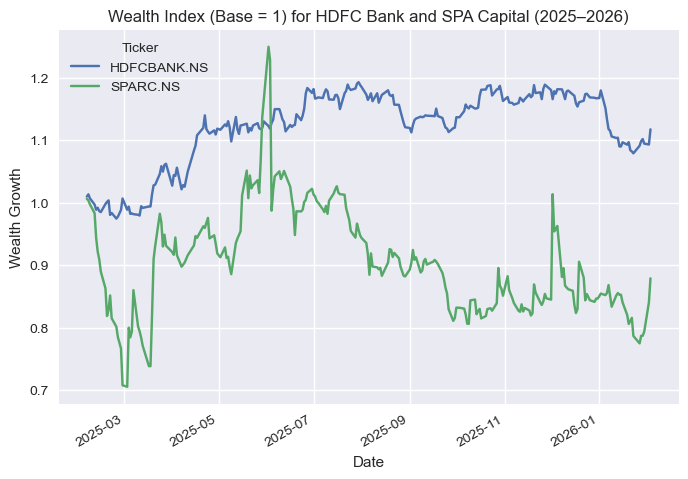

In [104]:
plt.figure(figsize=(10,6))

wealth_index.plot()

plt.title("Wealth Index (Base = 1) for HDFC Bank and SPA Capital (2025–2026)")
plt.xlabel("Date")
plt.ylabel("Wealth Growth")
plt.grid(True)

plt.show()


In [105]:
cumulative = (1 + returns).cumprod()

wealth_index = (1 + returns).cumprod()


In [100]:
running_max = cumulative.cummax()


In [101]:
drawdown = cumulative / running_max - 1


In [102]:
max_drawdown = drawdown.min()
max_drawdown


Ticker
HDFCBANK.NS   -0.095567
SPARC.NS      -0.380226
dtype: float64